## Nonlinear Option Pricing, Master 2 Probabilités et Finance, Sorbonne Université and École polytechnique


In this notebook, we provide a brief introduction to the main concepts and numerical implementations of neural networks, especially for the use in the course. We shall focus on feedforward neural networks with fullly connected layers, together with some coding examples of PyTorch.

In [1]:
# Import modules 
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from datetime import datetime

torch.__version__

'2.0.1+cpu'

## 1. Forward model of the neural network

### A. Feed-forward neural network structures 

In this section, we introduce the forward model of a feed forward neural network. A feed forward neural network with $L$ hidden layers is defined in the following way
\begin{align}
h^{(0)} &= x, \\
  h^{(j)} &= \sigma_j \left( W^{(j)} h^{(j-1)} + b^{(j)} \right),  \quad j = 1, \ldots, L \\
  y &= \sigma_{L+1}\left(W^{(L+1)} h^{(L)} + b^{(L+1)}\right),
\end{align}
where
<ul>
    <li>$x \in \mathbb R^{d_0}$ is the input. Each component of $x$ represents one feature of the input; The input layer does not have any trainable parameters.</li>
    <li>$h^{(j)} \in \mathbb R^{d_j}$ represents the output of the $j$-th hidden layer, where $d_j$ is called the width of that hidden layer.
        <ul><li>$W^{(j)} \in \mathbb R^{d_{j} \times d_{j-1}}$ and $b^{(j)} \in \mathbb R^{d_{j}}$ are the weights and biases of the $j$-th layer;</li>
            <li>$\sigma_j(\cdot)$ is a nonlinear activation function.</li>
        </ul></li>
    <li>$y\in\mathbb{R}^{d_{L+1}}$ denotes the output of the output layer.</li>
</ul>

### B. Nonlinear activation functions

Activation functions are used to generate non-linearities in a neural network. Remember that if linear activations (in fact, no activations) are used throughout all layers, then the whole forward model is still linear since the composition of two linear functions is a linear fucntion.

Below we introduce some commonly used activation functions. Please remember that the same activation function is applied to each neuton separately in a layer.

<ul>
    <li>Sigmoid function: <code>nn.Sigmoid()(x)</code>
        $$\sigma(x) = \frac{1}{1 + e^{-x}}$$
    </li>
    <li>Tanh function: <code>nn.Tanh()(x)</code>
        $$\tanh(x) = \frac{e^x - e^{-x}}{e^{x} + e^{-x}} = 2 \sigma(2 x)  - 1$$
    </li>
    <li>Relu function: <code>nn.ReLU()(x)</code>
        $$\text{ReLU}(x) = \max (0, x)$$
    </li>
    <li>Leaky ReLU function: <code>nn.LeakyReLU(negative_slope)(x)</code>
        $$\text{LeakyReLU}(x) = \mathbb{1}_{x < 0 }(x) \cdot (\alpha x) + \mathbb{1}_{x \geq 0}(x) \cdot (x)$$
    </li>
    <li>ELU function: <code>nn.ELU(alpha)(x)</code>
        $$\text{ELU}_{\alpha}(x)=\begin{cases} \alpha\left(e^x-1\right) & \text{if }x<0\\ x & \text{if }x\geq 0\end{cases}$$
    </li>
</ul>

<ul>
    <li>ReLU function is one of the most popular activation function in practice, mostly because it does not saturate for positive values and is computationally efficient. However it suffers from the dying ReLU problem (zero gradients from units with negative inputs)</li>
    <li>Variants of the ReLU function, such as Leakly ReLU and ELU, can be used to overcome the dead neurons problem.</li>
    <li>With $\alpha=1$, the ELU function is smooth everywhere, which may speed up training with gradient descent..</li>
</ul>

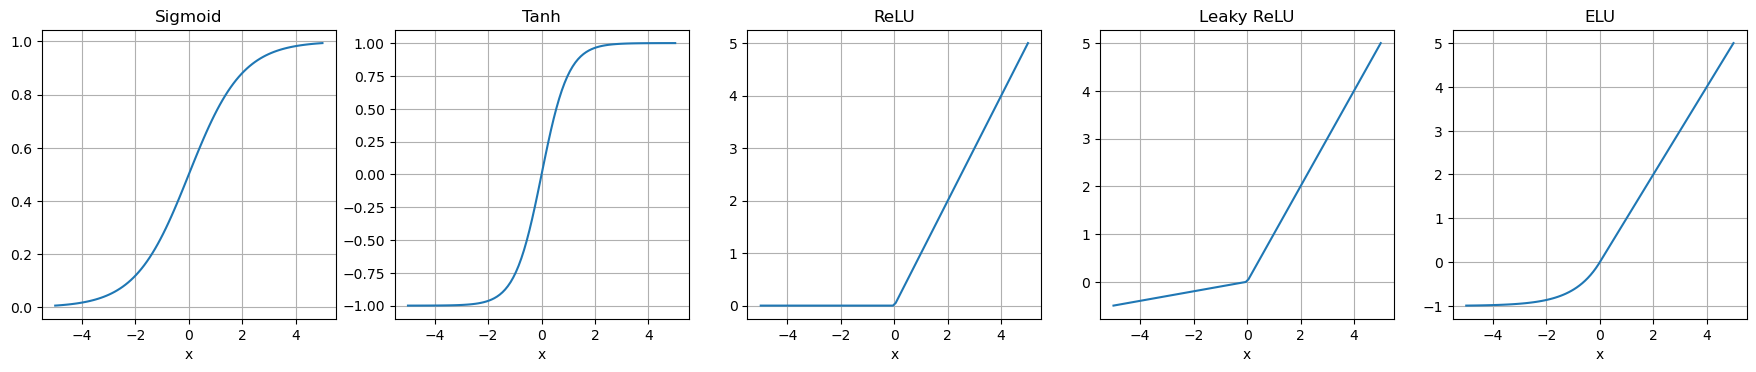

In [2]:
fig, axs = plt.subplots(1, 5, figsize=(22, 3.75))
x = torch.linspace(-5, 5, 100)
axs[0].plot(x, nn.Sigmoid()(x))
axs[0].set_title('Sigmoid')
axs[1].plot(x, nn.Tanh()(x))
axs[1].set_title('Tanh')
axs[2].plot(x, nn.ReLU()(x))
axs[2].set_title('ReLU')
axs[3].plot(x, nn.LeakyReLU(negative_slope=0.1)(x))
axs[3].set_title('Leaky ReLU')
axs[4].plot(x, nn.ELU(alpha=1.0)(x))
axs[4].set_title('ELU')
for ax in axs:
    ax.set_xlabel('x')
    ax.grid(True)

### C. Weights Initialization
The initial weights are typically randomized to break the symmetry. Normal or uniform distributions are commonly used. The means are typically set to be zero whereas the variances are chosen according to the numbers of inputs and outputs of the layer, and the activation function used. There are several initialization strategies that have proven to work very well in practice, such as LeCun uniform and normal, Glorot/Xavier uniform and normal, He/Kaiming uniform and normal.

The following is an example of feed-forward neural networks implemented in pytorch.

In [3]:
model = nn.Sequential(
    nn.Linear(2, 30), nn.ReLU(),
    nn.Linear(30, 30), nn.ReLU(),
    nn.Linear(30, 1)
)

model

Sequential(
  (0): Linear(in_features=2, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=30, bias=True)
  (3): ReLU()
  (4): Linear(in_features=30, out_features=1, bias=True)
)

## 2. Training Deep Neural Networks

### A. Loss function

As we discussed above, we need to find the optimal weights and biases such that the neural network prediction is close to the truth. Thus, we need some metric to measure this difference and we usually refer to this metric as the loss function. 

<ul>
    <li>Mean Squared Error (MSE): <code>nn.MSELoss</code>
        $$\text{MSE} (Y, \hat Y) = \frac 1 n \sum_{i}^n (Y_i - \hat Y_i)^2 = \frac 1 n \| Y- \hat Y\|_2^2$$
    </li>
    <li>Mean Absolute Error (MAE): <code>nn.L1Loss</code>
        $$\text{MAE} (Y, \hat Y) = \frac 1 n \sum_{i}^n |Y_i - \hat Y_i| = \frac 1 n \| Y- \hat Y\|_1$$
    </li>
    <li>Huber Loss: <code>nn.HuberLoss</code>
        $$\text{Huber}(Y, \hat{Y})=  \begin{cases} 
      \text{MSE} (Y, \hat Y) & \text{MAE} (Y, \hat Y) \leq \delta \\
      \delta \text{MAE} (Y, \hat Y) - \frac 1 2 \delta^2 & \text{otherwise}.
   \end{cases}$$
    </li>
    <li>Binary Cross Entropy: <code>nn.BCELoss</code>
        $$H(p,\hat{p})=  -\left[p\log(\hat{p})+(1-p)\log(1-\hat{p})\right]$$
    </li>
</ul>

### B. Chain rule and reverse-mode autodiff

Once we have defined the loss function, we can compute error gradients (gradients of loss with respect to neural network weights) and use gradient-based algorithms to find optimal weights to minimize the loss.

The error gradients in a neural network can be efficiently computed by <em>reverse-mode automatic differentiation</em>. With automatic differentiation, derivatives can be computed efficiently to machine precision. There are two basic modes of automatic differentiation: <em>forward</em> and <em>backward</em>. Both of them are based on the Chain Rule:
$$\frac{\partial J}{\partial \theta}=\sum_i\frac{\partial J}{\partial u_i}\frac{\partial u_i}{\partial \theta}.$$

The reverse mode is more efficient for functions with a few outputs and many inputs. Some references on forward and reverse modes:
<ul>
    <li> Chapter 8 of <em>Numerical Optimization</em> by Jorge Nocedal and Stephen Wright</li>
    <li> https://auto-ed.readthedocs.io/en/latest/mod3.html </li>
</ul>

In summary, a neural network makes predictions and compute the error in the forward pass; then by the chain rule error gradients are propagated backward through all the layers in the backward pass; and these gradients are used in the gradient desent step to update all the weights and reduce the error.
    
In the following, we will show an example on how to compute gradients in pytorch.

In [4]:
# A simple example of autodifferentiation of a linear model with MSE loss
torch.random.manual_seed(0) # Set seed for replication
w = torch.randn((4, 2), requires_grad=True)
b = torch.randn((4, 1), requires_grad=True)

x = torch.tensor([[1.], [2.]])
y = torch.randn((4, 1))
y_hat = torch.matmul(w, x) + b
loss = nn.MSELoss()(y, y_hat)
loss.backward()
print('Gradient of loss w.r.t. w: \n', w.grad.numpy())
print('Gradient of loss w.r.t. b: \n', b.grad.numpy())

Gradient of loss w.r.t. w: 
 [[ 0.5457777  1.0915554]
 [-1.2729373 -2.5458746]
 [-1.7035806 -3.4071612]
 [ 1.0693674  2.1387348]]
Gradient of loss w.r.t. b: 
 [[ 0.5457777]
 [-1.2729373]
 [-1.7035806]
 [ 1.0693674]]


### C. Optimization algorithms

Now, we have the access to the gradient of each parameter (weight and bias) inside the neural networks. We can update the params via different optimization algorithms. We will introduce some widely-used algorithms, e.g., gradient descent method and its variants, momentum and Adam methods and provides a brief discussion on the property of each method. For simplicity, we denote all the parameters as $\theta$ and the loss function to be minimized as $J(\theta)$. We also assume that we already know how to compute the gradient following the Chain rule and denote it as $\nabla_{\theta} J(\theta)$.

### (Stochastic) Gradient descent and its variants

Vanilla gradient descent algorithm was first proposed by Cauchy, dating back to 1847. The idea is to take repeated steps in the opposite direction of the gradient of the loss function at the current point since this is the direction of steepest descent. Other variants of the gradient descent method are designed by replacing the true gradient with some approximations of the gradient due to consideration of computational efficiency.

1) <b>Batch gradient descent</b>

Vanilla (batch) gradient descent algorithm is employed as below

\begin{align}
 \theta^{(i+1)} = \theta^{(i)} - \eta \cdot \nabla_{\theta} J(\theta^{(i)}),
\end{align}

where $\theta^{(i)}$ and $\nabla_{\theta} J(\theta^{(i)})$ are the value and the gradient of parameters of the $i$-th iteration, respectively. $\eta$ denotes the stepsize (learning rate), which controls the magnitude of the changes. Batch gradient descent method is more general, but can be very slow for huge datasets. In addition, it may laso get stuck in a local minimum.

2) <b>Stochastic gradient descent</b>

Instead of using training set, stochastic gradient descent (SGD) algorithm performs the gradient update based on a random instance:

\begin{align}
 \theta^{(i+1)} = \theta^{(i)} - \eta \cdot \nabla_{\theta} J(\theta^{(i)}; x_j, y_j),
\end{align}

where $\{ x_j, y_j \}$ is the $j$-th data, which is picked from the training dataset randomly. Obviously SGD algorithm benefits from fast gradient computation. However, the gradient can be pretty noisy 
and the loss may fluctuate a lot and decrease only on average. However, the randomness may help the algorithm escape from local minima.

3) <b>Mini-batch gradient descent</b>: <code>torch.optim.SGD(params, lr)</code>

Mini-batch gradient descent algorithm combines these two algorithms and update the parameters with a mini-batch of $m$ training data:

\begin{align}
 \theta^{(i+1)} = \theta^{(i)} - \eta \cdot \nabla_{\theta} J(\theta^{(i)}; \{x_{j_k}\}_{k=1}^m, \{y_{j_k}\}_{k=1}^m),
\end{align}

where $\{x_{j_k}, y_{j_k}\}_{k=1}^m)$ are $m$ data drawn from the training dataset randomly. Mini-batch gradient descent algorithm is fast and also reduces the variance of each gradient update and thus it has desirable property of stability.


In the following, we also briefly introduce two variants of gradient descent method which can be turned on as one argument in built-in SGD algorithm in pytorch. 

4) <b>Momentum algorithm</b>: <code>torch.optim.SGD(params, lr, momentum=0.9)</code>

Once we have the access to the gradient at $i$-th iteration (can be full batch or mini-batch), we can use momentum algorithm to accelerate gradient descent algorithm. The algorithm is given by

\begin{align}
 v^{(i)} &= \gamma \cdot v^{(i-1)} + \eta \cdot \nabla_{\theta} J(\theta^{(i)}) \\
 \theta^{(i+1)} &= \theta^{(i)} - v^{(i)}.
\end{align}

Just like the momentum in physics, when we update the parameters, we also would like to use the information of history updates. This results in a faster convergence and reduces the variance of the updates. The momentum value $\gamma$ of $0.9$ usually works well in practice.

5) <b>Nesterov algorithm</b>: <code>torch.optim.SGD(params, lr, momentum=0.9, nesterov=False)</code>

The Nesterov algorithm can be viewed as an implicit version of momentum algorithm, which is given in the form

\begin{align}
 v^{(i)} &= \gamma \cdot v^{(i-1)} + \eta \cdot \nabla_{\theta} J(\theta^{(i)} - \gamma v^{(i-1)}) \\
 \theta^{(i+1)} &= \theta^{(i)} - v^{(i)}.
\end{align}



Last but not the least, the value of the stepsize (learning rate) $\eta$ is crucial in the practical problems. For the algorithms above, we all set $\eta$ to a constant. A large $\eta$ usually results in fast converge at the beginning, but it can skip the global minimum or good local minimum for nonconvex optimization problems. In contrast, a small $\eta$ suffers from slow convergence and it may also stuck at some bad local minima at first several steps. Thus, we have to be very careful about the choice of $\eta$. In practice, one may use a large learning rate at the beginning and then decrease it with some criterion. We can also use some algorithms with adaptive learning rate such as Adam algorithm, which we will introduce later.  

### Adaptive moment estimation (Adam)

<code>torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999))</code>

Adam is a method that uses adaptive learning rate for the update. The updating rule is given by
\begin{align}
 m^{(i)} &= \beta_1 \cdot m^{(i-1)} + (1 - \beta_1) \cdot \nabla_{\theta} J(\theta^{(i)}) \\
 v^{(i)} &= \beta_2 \cdot  v^{(i-1)} + (1 - \beta_2) \cdot \nabla_{\theta} J(\theta^{(i)})^2 \\
 \theta^{(i+1)} &= \theta^{(i)} - \frac{\eta}{\sqrt{\frac{v^{(i)}}{1 - (\beta_2)^i}} + \epsilon} \cdot \frac{m^{(i)}}{1 - (\beta_1)^i}
\end{align}
where $\epsilon$ avoids zero in the denominator. Adam keeps using history gradients as in the momentum method and adaptively changes the learning rate with history information at the same time. The default values $\beta_1 = 0.9$, $\beta_2 = 0.999$ and $\epsilon = 10^{-7}$ usually work well in practice.

A good reference on gradient descent optimization is https://ruder.io/optimizing-gradient-descent/.

## 3. Putting together: Build your own neural networks

In this section, we provide a hands-on project on predicting the fuel efficiency, which is a regression problem. We will build our own neural network and train it on a training dataset. We also measure the performance of the trained neural network on a test dataset. This offers you a guideline of stuyding regression problems with neural networks step by step. 

In [5]:
# Import modules 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd   # You need to install pandas to import data


# Make numpy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

### 1) Data import and preprocessing

In [6]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']
raw_dataset = pd.read_csv(url, names=column_names, index_col=False, usecols=range(len(column_names)), na_values='?', sep='\s+', skipinitialspace=True)
raw_dataset.tail(4)  # Display last 4 rows of the raw data

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [7]:
raw_dataset = raw_dataset.dropna(axis=0, how='any')  # Throw away samples with missing values
raw_dataset['Origin'] = raw_dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(raw_dataset, columns=['Origin'], prefix='', prefix_sep='') # Convert categorical variable into dummy variables.
dataset.tail(4)  # Display last 4 rows of the data

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
394,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,0,0,1


In [8]:
# Split the data into training dataset and testing dataset
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

# We split the data into features and output variable.
train_features = train_dataset.copy()
test_features = test_dataset.copy()
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

In [9]:
# Normalize features

# train_features.describe() computes the mean and std for you
train_stats = train_features.describe().transpose()[['mean', 'std']]

def normalize(x):
    return (x - train_stats['mean']) / train_stats['std']

train_features = normalize(train_features)
test_features = normalize(test_features)

In [10]:
train_features = np.asarray(train_features)
train_labels = np.asarray(train_labels)[:, np.newaxis]
test_features = np.asarray(test_features)
test_labels = np.asarray(test_labels)[:, np.newaxis]

In [11]:
batch_size = 32
train_size = int(train_features.shape[0]*0.8)

# Prepare training data to loop through
train_dataset = TensorDataset(
    torch.tensor(train_features[:train_size], dtype=torch.float32), 
    torch.tensor(train_labels[:train_size], dtype=torch.float32)
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Prepare validation data for evaluation after each epoch
X_valid_tensor = torch.tensor(train_features[train_size:], dtype=torch.float32) 
Y_valid_tensor = torch.tensor(train_labels[train_size:], dtype=torch.float32)

### 2) Build NN model

In [12]:
learning_rate = 1e-3
hidden_size   = 30

# define the neural network. Use ReLU activation function and default weight initializer
model = nn.Sequential(
    nn.Linear(train_features.shape[-1], hidden_size), nn.ReLU(),
    nn.Linear(hidden_size, hidden_size), nn.ReLU(),
    nn.Linear(hidden_size, 1)
)
loss_fn   = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

### 3) Train the NN

In [13]:
epochs       = 100     # Max number of epochs of training

train_losses = []
valid_losses = []

for epoch in range(1, epochs+1):
    train_loss = 0.
    # Loop through training data to train
    for i, (X, Y) in enumerate(train_dataloader):
        loss  = loss_fn(model(X), Y)    
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    train_loss /= len(train_dataloader)
    train_losses.append(train_loss)
        
    # Evaluate validaiton for early stopping and monitoring
    with torch.no_grad():
        valid_loss = loss_fn(model(X_valid_tensor), Y_valid_tensor).item()
    valid_losses.append(valid_loss)

    # Print epoch summary
    print(f"Epoch: {epoch:02}/{epochs} Training Loss: {train_loss:.4f} - Validation Loss: {valid_loss:.4f}")

Epoch: 01/100 Training Loss: 23.0845 - Validation Loss: 23.4940
Epoch: 02/100 Training Loss: 22.8829 - Validation Loss: 23.3081
Epoch: 03/100 Training Loss: 22.6852 - Validation Loss: 23.0848
Epoch: 04/100 Training Loss: 22.5135 - Validation Loss: 22.7930
Epoch: 05/100 Training Loss: 22.1560 - Validation Loss: 22.3928
Epoch: 06/100 Training Loss: 21.8105 - Validation Loss: 21.8579
Epoch: 07/100 Training Loss: 21.2405 - Validation Loss: 21.1625
Epoch: 08/100 Training Loss: 20.5108 - Validation Loss: 20.2728
Epoch: 09/100 Training Loss: 19.6078 - Validation Loss: 19.1424
Epoch: 10/100 Training Loss: 18.4713 - Validation Loss: 17.7494
Epoch: 11/100 Training Loss: 17.0776 - Validation Loss: 16.0432
Epoch: 12/100 Training Loss: 15.3992 - Validation Loss: 14.0027
Epoch: 13/100 Training Loss: 13.4036 - Validation Loss: 11.8233
Epoch: 14/100 Training Loss: 11.3002 - Validation Loss: 9.7406
Epoch: 15/100 Training Loss: 9.2609 - Validation Loss: 7.9198
Epoch: 16/100 Training Loss: 7.4116 - Valid

(0.0, 10.0)

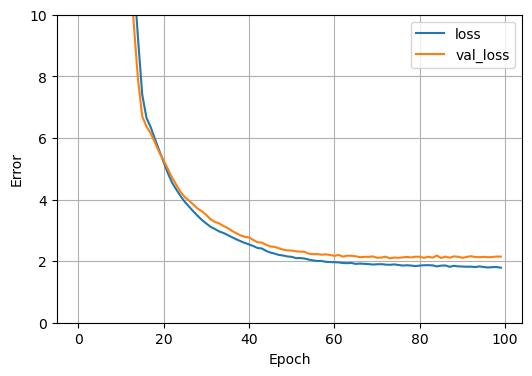

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(epochs), train_losses, label='loss')
ax.plot(range(epochs), valid_losses, label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Error')
ax.grid(True)
ax.legend(loc=0)
ax.set_ylim(0, 10)

### 4) Evaluation of the NN on the test dataset

In [15]:
# Test error on the test dataset
model.eval()
test_preds = model(torch.tensor(test_features, dtype=torch.float32))
test_loss = loss_fn(test_preds, torch.tensor(test_labels, dtype=torch.float32)).item()

print('Test Loss: ', test_loss)

Test Loss:  1.7467434406280518


Text(0.5, 1.0, 'Comparison between predictions and truth')

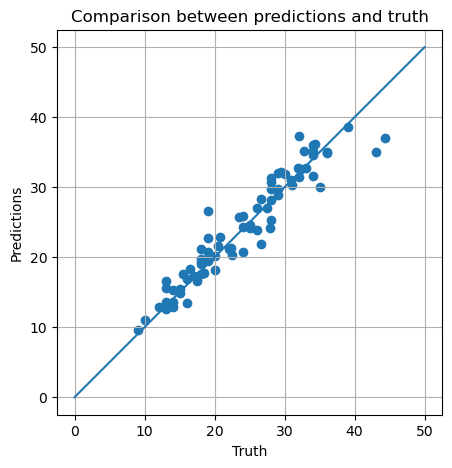

In [16]:
# We compare the predictions and truth in a plot

# test_preds = np.squeeze(model(torch.tensor(test_features, dtype=torch.float32)).detach().numpy())

fig, ax = plt.subplots(figsize=(5, 5))
ax.grid(True)
ax.scatter(test_labels, np.squeeze(test_preds.detach().numpy()))
ax.set_xlabel('Truth')
ax.set_ylabel('Predictions')
ax.plot([0, 50], [0,50])
ax.set_aspect('equal')
ax.set_title('Comparison between predictions and truth')